# Prerequisits

In [11]:
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, f1_score
from tqdm import tqdm
tqdm.pandas()


TOP_N = 20
SEED = 12345

# Temperature Scaling Confidence Calibration

## Instructions

* To perform confidence calibration using Temperature Scaling, we modified the inference server to return the average log-probability of the generated tokens instead of the product of token probabilities.
* We first executed the complete inference workflow for both evaluation datasets (balanced distribution and operational distribution) using the script `Evaluation/evaluation.py`.
* After the inference stage, probability calibration was performed using the script `Evaluation/t_estimator.py`.
* The calibrated confidence scores produced by `Evaluation/t_estimator.py` were subsequently used in all confidence analyses, reliability diagrams, Expected Calibration Error (ECE) calculations, and ensemble evaluations reported in the paper.

# Qualitative Error Analysis

## Dataset Read

In [4]:
data = pd.read_csv("./Datasets/10a_BalancedCalibratedResults.csv")
data.columns

Index(['Label', 'DINAMICA', 'N1 llama Classification', 'N1 llama Pred Proba',
       'N1 llama Pred Log Proba', 'N2 llama Classification',
       'N2 llama Pred Proba', 'N2 llama Pred Log Proba',
       'N3 llama Classification', 'N3 llama Pred Proba',
       'N3 llama Pred Log Proba', 'Llama Final Prediction Proba',
       'N1 fine_llama Classification', 'N1 fine_llama Pred Proba',
       'N1 fine_llama Pred Log Proba', 'N2 fine_llama Classification',
       'N2 fine_llama Pred Proba', 'N2 fine_llama Pred Log Proba',
       'N3 fine_llama Classification', 'N3 fine_llama Pred Proba',
       'N3 fine_llama Pred Log Proba', 'Fine Llama Final Prediction Proba',
       'N1 ML Classification', 'N1 Pred Proba', 'N2 ML Classification',
       'N2 Pred Proba', 'N3 ML Classification', 'N3 Pred Proba',
       'ML Final Prediction Proba', 'Label_N1', 'Label_N2', 'Label_N3',
       'Joint Classification', 'ML + Llama', 'ML + Fine Llama',
       'Llama + Fine Llama', 'N1 llama Correct', 'N2 llama C

## Functions

In [5]:
# Separate real level errors from propagated errors
def hierarchical_error_analysis(
    df,
    model_name,
    pred_cols,
    correct_cols,
    label_cols=("Label_N1", "Label_N2", "Label_N3"),
    top_n=TOP_N
):

    n1_pred, n2_pred, n3_pred = pred_cols
    n1_correct_col, n2_correct_col, n3_correct_col = correct_cols
    n1_true, n2_true, n3_true = label_cols

    work = df.copy()

    # Garante que as colunas de acerto estejam como inteiros 0/1
    work[n1_correct_col] = work[n1_correct_col].astype(int)
    work[n2_correct_col] = work[n2_correct_col].astype(int)
    work[n3_correct_col] = work[n3_correct_col].astype(int)

    # ------------------------------
    # Erros locais reais
    # ------------------------------

    # N1: qualquer erro em N1 é erro real de N1
    n1_real_errors = work[
        work[n1_correct_col] == 0
    ].copy()

    # N2: só analisa erro de N2 quando N1 estava correto
    n2_real_errors = work[
        (work[n1_correct_col] == 1) &
        (work[n2_correct_col] == 0)
    ].copy()

    # N3: só analisa erro de N3 quando N2 estava correto
    n3_real_errors = work[
        (work[n2_correct_col] == 1) &
        (work[n3_correct_col] == 0)
    ].copy()

    print("=" * 90)
    print(f"MODEL: {model_name}")
    print("=" * 90)

    print("\nResumo hierárquico de erros:")
    print(f"N1 real errors: {len(n1_real_errors)}")
    print(f"N2 real errors after correct N1: {len(n2_real_errors)}")
    print(f"N3 real errors after correct N2: {len(n3_real_errors)}")
    print(f"Total: {len(n1_real_errors) + len(n2_real_errors) + len(n3_real_errors)}")

    print("\nTop true N1 classes with real errors:")
    display(
        n1_real_errors[n1_true]
        .value_counts()
        .head(top_n)
        .reset_index()
        .rename(columns={"index": "True N1 Class", n1_true: "Errors"})
    )

    print("\nTop true N2 classes with real errors, only where N1 was correct:")
    display(
        n2_real_errors[n2_true]
        .value_counts()
        .head(top_n)
        .reset_index()
        .rename(columns={"index": "True N2 Class", n2_true: "Errors"})
    )

    print("\nTop true N3 classes with real errors, only where N2 was correct:")
    display(
        n3_real_errors[n3_true]
        .value_counts()
        .head(top_n)
        .reset_index()
        .rename(columns={"index": "True N3 Class", n3_true: "Errors"})
    )

    return {
        "model": model_name,
        "work": work,

        "n1_real_errors": n1_real_errors,
        "n2_real_errors": n2_real_errors,
        "n3_real_errors": n3_real_errors,
    }

In [6]:
# Classification confusion pairs
def confusion_pairs(error_df, true_col, pred_col, top_n=TOP_N):

    pairs = (
        error_df
        .groupby([true_col, pred_col])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(top_n)
    )

    return pairs

In [7]:
# Consolidate confusion pairs
def consolidate_confusion_pairs(model_name, errors, top_n=TOP_N):
    conf_n1 = confusion_pairs(
        errors["n1_real_errors"],
        "Label_N1",
        f"N1 {model_name} Classification",
        top_n=top_n
    )
    conf_n1["Level"] = "N1"

    conf_n2 = confusion_pairs(
        errors['n2_real_errors'],
        "Label_N2",
        f"N2 {model_name} Classification",
        top_n=TOP_N
    )
    conf_n2["Level"] = "N2"

    conf_n3 = confusion_pairs(
        errors['n3_real_errors'],
        "Label_N3",
        f"N3 {model_name} Classification",
        top_n=TOP_N
    )
    conf_n3["Level"] = "N3"

    confusions = pd.concat(
        [
            conf_n1.rename(columns={
                "Label_N1": "True_Label",
                f"N1 {model_name} Classification": "Predicted_Label"
            }),
            conf_n2.rename(columns={
                "Label_N2": "True_Label",
                f"N2 {model_name} Classification": "Predicted_Label"
            }),
            conf_n3.rename(columns={
                "Label_N3": "True_Label",
                f"N3 {model_name} Classification": "Predicted_Label"
            }),
        ],
        ignore_index=True
    )

    confusions = confusions[
        ["Level", "True_Label", "Predicted_Label", "count"]
    ]

    return confusions

In [8]:
# Print confusion pairs per class
def print_cases(category, confusions):
    print(f"{category}:")
    for i in confusions[confusions['Review'] == category]['pair_key']:
        print(f"{i[0]} → {i[1]}")

    print("")

In [9]:
# Translating classes
category_map = {
    "Delitos relacionados": "Semantic overlap confusion",
    "Categoria genérica e subtipo específico": "Generic-versus-specific subtype confusion",
    "Estados do mesmo processo operacional": "Operational workflow confusion",
    "Coexistência de delitos": "Crimes coexistence confusion"
}

def maping_category(row):
    row['Final_category'] = category_map[row['Review']]
    return row

In [10]:
def analysis(confusions):
    # Class Summary
    print("Class Summary:")
    category_summary = confusions.groupby("Review")["count"].sum().reset_index().sort_values("count", ascending=False)
    category_summary["percentage"] = category_summary["count"] / category_summary["count"].sum() * 100
    display(category_summary)

    
    # Class Summary by Level
    print("\n\nClass Summary by Level:")
    category_by_level = confusions.groupby(["Level", "Review"])["count"].sum().reset_index().sort_values(["Level", "count"], ascending=[True, False])
    category_by_level["level_percentage"] = category_by_level.groupby("Level")["count"].transform(lambda x: (x / x.sum() * 100))
    display(category_by_level)

    
    # Class Summary by Level pivot
    print("\n\nClass Summary by Level pivot:")
    category_pivot = confusions.pivot_table(
        index="Review",
        columns="Level",
        values="count",
        aggfunc="sum",
        fill_value=0
    )
    category_pivot["Total"] = category_pivot.sum(axis=1)
    category_pivot = category_pivot.sort_values("Total", ascending=False)
    display(category_pivot)

    
    # Class Summary by Level pivot percent by line
    print("\n\nClass Summary by Level pivot percent by line:")
    pivot_counts = confusions.pivot_table(
        index="Review",
        columns="Level",
        values="count",
        aggfunc="sum",
        fill_value=0
    )
    pivot_counts["Total"] = pivot_counts.sum(axis=1)
    row_pct = pivot_counts.div(
        pivot_counts["Total"],
        axis=0
    ) * 100
    row_display = pivot_counts.copy()
    for col in pivot_counts.columns:
        row_display[col] = [
            f"{count} ({pct:.1f}%)"
            for count, pct in zip(
                pivot_counts[col],
                row_pct[col]
            )
        ]
    display(row_display)


    # Class Summary by Level pivot percent by column
    print("\n\nClass Summary by Level pivot percent by column:")
    pivot_counts = confusions.pivot_table(
        index="Review",
        columns="Level",
        values="count",
        aggfunc="sum",
        fill_value=0
    )
    # Percentuais por coluna
    col_pct = pivot_counts.div(
        pivot_counts.sum(axis=0),
        axis=1
    ) * 100
    # Monta a tabela exibindo count + %
    col_display = pivot_counts.copy()
    for col in pivot_counts.columns:
        col_display[col] = [
            f"{count} ({pct:.1f}%)"
            for count, pct in zip(
                pivot_counts[col],
                col_pct[col]
            )
        ]
    # Adiciona linha Total
    col_display.loc["Total"] = [
        f"{pivot_counts[col].sum()} (100.0%)"
        for col in pivot_counts.columns
    ]
    display(col_display)


    # Top 3 confusion pairs of each class
    print("\n\nTop 3 confusion pairs of each class:")
    top_examples_by_category = confusions.sort_values(["Review", "count"], ascending=[True, False]).groupby("Review").head(3).reset_index(drop=True)
    display(top_examples_by_category[["Review", "Level", "True_Label", "Predicted_Label", "count"]])
    

In [11]:
def read_classifications(filepath, translate=1):
    # AI and human domain professional errors classifications
    confusions_classified = pd.read_csv(filepath)

    # Symetric pair verification
    print("Symetric pair verification:")
    confusions_classified["pair_key"] = confusions_classified.apply(lambda row: tuple(sorted([row["True_Label"], row["Predicted_Label"]])), axis=1)
    display(confusions_classified.groupby("pair_key")["Review"].nunique())

    # AI and human differences
    print("\n\nAI and human differences:")
    display(confusions_classified[confusions_classified['Error_Category'] != confusions_classified['Review']])

    # Translating classes names
    if translate == 1:
        confusions_classified = confusions_classified.apply(maping_category, axis=1)

    # Print classes pairs
    print("\n\nClass Pairs:")
    print_cases("Semantic overlap confusion", confusions_classified)
    print_cases("Generic-versus-specific subtype confusion", confusions_classified)
    print_cases("Operational workflow confusion", confusions_classified)
    print_cases("Crimes coexistence confusion", confusions_classified)

    # Translating classes names
    return confusions_classified

## Fine-Llama

### Real Errors per Level (remove propagation)

In [26]:
fine_errors = hierarchical_error_analysis(
    data,
    'fine_llama',
    ['N1 fine_llama Classification', 'N2 fine_llama Classification', 'N3 fine_llama Classification'],
    ['N1 fine_llama Correct', 'N2 fine_llama Correct', 'N3 fine_llama Correct'],
    label_cols=("Label_N1", "Label_N2", "Label_N3"),
    top_n=TOP_N
)

MODEL: fine_llama

Resumo hierárquico de erros:
N1 real errors: 272
N2 real errors after correct N1: 215
N3 real errors after correct N2: 307
Total: 794

Top true N1 classes with real errors:


,Errors,count
0,Crimes Contra Pessoa,108
1,Recuperação de Veículo ou Atos Administrativos...,76
2,Crimes Contra Propriedade,42
3,Violação ou Perturbação ou Dano ou Exercício A...,17
4,Crimes de Trânsito ou Meio Ambiente,12
5,"Relacionados a Drogas, Entorpecentes e Porte d...",11
6,"Resistência, Desacato ou Desobediência",6



Top true N2 classes with real errors, only where N1 was correct:


,Errors,count
0,Furto,28
1,Lei de Drogas (Outros) (Lei 11.343/06),23
2,Ameaça ou Injúria ou Perseguição ou Dano ou Ex...,20
3,Tráfico de Drogas (Lei 11.343/06),18
4,Associação para Tráfico de Droga (Lei 11.343/06),17
5,Lesão Corporal,16
6,Registro de Um Acontecimento,14
7,Atos Administrativos,11
8,Resistência,10
9,Desacato,8



Top true N3 classes with real errors, only where N2 was correct:


,Errors,count
0,Roubo outros,23
1,Lesão Corporal Culposa (outros) (Lei 9503/97),20
2,Desaparecimento outros,19
3,Furto outros,16
4,Furto a Transeunte,14
5,Lesão Corporal (outros),13
6,Recuperação de Veículo Furtado,13
7,Furto no Interior de Estabelecimento Comercial,12
8,Difamação,11
9,Roubo a Transeunte,10


### Confusion Pairs

In [27]:
fine_confusions = consolidate_confusion_pairs("fine_llama", fine_errors)
fine_confusions.to_csv("./QualitativeAnalysis/fine_llama_confusions.csv", index=False)

Instructions

* After identifying the top-N confusion pairs for each hierarchical level, a domain specialist manually reviewed the results and assigned each error to one of the four qualitative error categories described in `QualitativeAnalysis/ErrorCategories.md`.
* The categorization process was performed after extracting the confusion pairs and before the aggregation of qualitative error statistics reported in the paper.

### Confusion Classes

In [28]:
fine_confusions_classified = read_classifications("./QualitativeAnalysis/fine_llama_confusions_classified.csv")
fine_confusions_classified.head()

Symetric pair verification:


pair_key
(Ameaça ou Injúria ou Perseguição ou Dano ou Extorsão, Descumprimento de Medidas Protetivas de Urgência)                                   1
(Ameaça ou Injúria ou Perseguição ou Dano ou Extorsão, Lesão Corporal)                                                                     1
(Apropriação Indébita (outros), Furto)                                                                                                     1
(Associação para Tráfico de Droga (Lei 11.343/06), Lei de Drogas (Outros) (Lei 11.343/06))                                                 1
(Associação para Tráfico de Droga (Lei 11.343/06), Porte Ilegal de Arma de Fogo de Uso Restrito)                                           1
(Associação para Tráfico de Droga (Lei 11.343/06), Tráfico de Drogas (Lei 11.343/06))                                                      1
(Atos Administrativos, Recuperação de Veículo)                                                                                             1
(Ato



AI and human differences:


,Level,True_Label,Predicted_Label,count,Error_Category,Review,pair_key
23,N2,Lei de Drogas (Outros) (Lei 11.343/06),Tráfico de Drogas (Lei 11.343/06),11,Delitos relacionados,Categoria genérica e subtipo específico,"(Lei de Drogas (Outros) (Lei 11.343/06), Tráfi..."
30,N2,Lei de Drogas (Outros) (Lei 11.343/06),Associação para Tráfico de Droga (Lei 11.343/06),6,Delitos relacionados,Categoria genérica e subtipo específico,(Associação para Tráfico de Droga (Lei 11.343/...
31,N2,Dano (outros),Violação de Domicílio,6,Delitos relacionados,Categoria genérica e subtipo específico,"(Dano (outros), Violação de Domicílio)"
42,N3,Recuperação de Veículo Furtado,Recuperação de Veículo Roubado,13,Estados do mesmo processo operacional,Delitos relacionados,"(Recuperação de Veículo Furtado, Recuperação d..."
58,N3,Roubo a Transeunte,Roubo de Telefone Celular,4,Categoria genérica e subtipo específico,Delitos relacionados,"(Roubo a Transeunte, Roubo de Telefone Celular)"




Class Pairs:
Semantic overlap confusion:

Generic-versus-specific subtype confusion:

Operational workflow confusion:

Crimes coexistence confusion:



,Level,True_Label,Predicted_Label,count,Error_Category,Review,pair_key,Final_category
0,N1,Crimes Contra Pessoa,Violação ou Perturbação ou Dano ou Exercício A...,41,Coexistência de delitos,Coexistência de delitos,"(Crimes Contra Pessoa, Violação ou Perturbação...",Crimes coexistence confusion
1,N1,Recuperação de Veículo ou Atos Administrativos...,Crimes Contra Propriedade,35,Estados do mesmo processo operacional,Estados do mesmo processo operacional,"(Crimes Contra Propriedade, Recuperação de Veí...",Operational workflow confusion
2,N1,Crimes Contra Pessoa,"Resistência, Desacato ou Desobediência",30,Coexistência de delitos,Coexistência de delitos,"(Crimes Contra Pessoa, Resistência, Desacato o...",Crimes coexistence confusion
3,N1,Crimes Contra Pessoa,Crimes de Trânsito ou Meio Ambiente,18,Coexistência de delitos,Coexistência de delitos,"(Crimes Contra Pessoa, Crimes de Trânsito ou M...",Crimes coexistence confusion
4,N1,Crimes Contra Propriedade,Recuperação de Veículo ou Atos Administrativos...,16,Estados do mesmo processo operacional,Estados do mesmo processo operacional,"(Crimes Contra Propriedade, Recuperação de Veí...",Operational workflow confusion


## Llama

### Real Erros per Level (remove propagation)

In [10]:
llama_errors = hierarchical_error_analysis(
    data,
    'llama',
    ['N1 Llama Classification', 'N2 Llama Classification', 'N3 Llama Classification'],
    ['N1 llama Correct', 'N2 llama Correct', 'N3 llama Correct'],
    label_cols=("Label_N1", "Label_N2", "Label_N3"),
    top_n=TOP_N
)

MODEL: llama

Resumo hierárquico de erros:
N1 real errors: 947
N2 real errors after correct N1: 433
N3 real errors after correct N2: 358
Total: 1738

Top true N1 classes with real errors:


,Errors,count
0,Recuperação de Veículo ou Atos Administrativos...,436
1,Crimes Contra Pessoa,136
2,Crimes Contra Propriedade,120
3,Violação ou Perturbação ou Dano ou Exercício A...,114
4,Crimes de Trânsito ou Meio Ambiente,55
5,"Resistência, Desacato ou Desobediência",51
6,"Relacionados a Drogas, Entorpecentes e Porte d...",35



Top true N2 classes with real errors, only where N1 was correct:


,Errors,count
0,Furto,118
1,Ameaça ou Injúria ou Perseguição ou Dano ou Ex...,46
2,Lesão Corporal,34
3,Lei de Drogas (Outros) (Lei 11.343/06),22
4,Associação para Tráfico de Droga (Lei 11.343/06),18
5,Desacato,18
6,Receptação,17
7,Atos Administrativos,16
8,Porte Ilegal de Arma de Fogo de Uso Restrito,16
9,Porte de Droga para Consumo Próprio (Lei 11.34...,16



Top true N3 classes with real errors, only where N2 was correct:


,Errors,count
0,Estelionato (outros) - Tentativa,26
1,Roubo a Estabelecimento Comercial,25
2,Furto a Estabelecimento Comercial,21
3,Roubo outros,18
4,Roubo de Veículo - Moto,16
5,Calúnia,15
6,Homicídio Provocado por Projétil de Arma de Fo...,15
7,Lesão Corporal (outros),14
8,Difamação,13
9,"Lesão Corporal Provocada por Socos, Tapas e Po...",13


### Confusion Pairs

In [11]:
llama_confusions = consolidate_confusion_pairs("llama", llama_errors)
llama_confusions.to_csv("./QualitativeAnalysis/llama_confusions.csv", index=False)

Instructions

* After identifying the top-N confusion pairs for each hierarchical level, a domain specialist manually reviewed the results and assigned each error to one of the four qualitative error categories described in `QualitativeAnalysis/ErrorCategories.md`.
* The categorization process was performed after extracting the confusion pairs and before the aggregation of qualitative error statistics reported in the paper.

### Confusion Classes

In [21]:
llama_confusions_classified = read_classifications("./QualitativeAnalysis/llama_confusions_classified.csv", translate=0)
llama_confusions_classified.head()

Symetric pair verification:


pair_key
(Ameaça ou Injúria ou Perseguição ou Dano ou Extorsão, Lesão Corporal)                                                                   1
(Apreensão de Substância Entorpecente, Porte de Droga para Consumo Próprio (Lei 11.343/06))                                              1
(Apreensão de Substância Entorpecente, Tráfico de Drogas (Lei 11.343/06))                                                                1
(Apropriação Indébita (outros), Estelionato)                                                                                             1
(Associação para Tráfico de Droga (Lei 11.343/06), Tráfico de Drogas (Lei 11.343/06))                                                    1
(Atos Administrativos, Recuperação de Veículo)                                                                                           1
(Calúnia, Injúria (outros))                                                                                                              1
(Crimes Contra Pes



AI and human differences:


,Level,True_Label,Predicted_Label,count,Error_Category,Review,pair_key
17,N1,Violação ou Perturbação ou Dano ou Exercício A...,Sem Classificação,6,Crimes coexistence confusion,Unclassified,"(Sem Classificação, Violação ou Perturbação ou..."
29,N2,Porte de Droga para Consumo Próprio (Lei 11.34...,Apreensão de Substância Entorpecente,12,Semantic overlap confusion,Operational workflow confusion,"(Apreensão de Substância Entorpecente, Porte d..."
30,N2,Receptação,Roubo,11,Semantic overlap confusion,Operational workflow confusion,"(Receptação, Roubo)"
31,N2,Resistência,Resistência qualificada,11,Semantic overlap confusion,Generic-versus-specific subtype confusion,"(Resistência, Resistência qualificada)"
34,N2,Estupro,Sem Classificação,9,Crimes coexistence confusion,Unclassified,"(Estupro, Sem Classificação)"
35,N2,Descumprimento de Medidas Protetivas de Urgência,Lesão Corporal,8,Semantic overlap confusion,Crimes coexistence confusion,(Descumprimento de Medidas Protetivas de Urgên...
36,N2,Tráfico de Drogas (Lei 11.343/06),Apreensão de Substância Entorpecente,7,Semantic overlap confusion,Operational workflow confusion,"(Apreensão de Substância Entorpecente, Tráfico..."
37,N2,Homicídio,Sem Classificação,7,Crimes coexistence confusion,Unclassified,"(Homicídio, Sem Classificação)"
49,N3,Roubo no Interior de Veículo,Roubo a Transeunte,9,Generic-versus-specific subtype confusion,Semantic overlap confusion,"(Roubo a Transeunte, Roubo no Interior de Veíc..."
53,N3,Furto no Interior de Coletivo,Furto a Transeunte,7,Generic-versus-specific subtype confusion,Semantic overlap confusion,"(Furto a Transeunte, Furto no Interior de Cole..."




Class Pairs:
Semantic overlap confusion:
Furto → Roubo
Ameaça ou Injúria ou Perseguição ou Dano ou Extorsão → Lesão Corporal
Ameaça ou Injúria ou Perseguição ou Dano ou Extorsão → Lesão Corporal
Desacato → Resistência qualificada
Desobediência → Resistência qualificada
Associação para Tráfico de Droga (Lei 11.343/06) → Tráfico de Drogas (Lei 11.343/06)
Estelionato → Furto
Homicídio → Lesão Corporal
Homicídio → Lesão Corporal
Roubo a Transeunte → Roubo no Interior de Veículo
Furto a Transeunte → Furto no Interior de Coletivo
Roubo a Transeunte → Roubo de Telefone Celular
Roubo a Estabelecimento Comercial → Roubo a Transeunte

Generic-versus-specific subtype confusion:
Lei de Drogas (Outros) (Lei 11.343/06) → Tráfico de Drogas (Lei 11.343/06)
Resistência → Resistência qualificada
Apropriação Indébita (outros) → Estelionato
Estelionato (outros) → Estelionato (outros) - Tentativa
Furto a Estabelecimento Comercial → Furto no Interior de Estabelecimento Comercial
Roubo a Estabelecimento Co

,Level,True_Label,Predicted_Label,count,Error_Category,Review,pair_key
0,N1,Recuperação de Veículo ou Atos Administrativos...,Crimes Contra Propriedade,232,Operational workflow confusion,Operational workflow confusion,"(Crimes Contra Propriedade, Recuperação de Veí..."
1,N1,Recuperação de Veículo ou Atos Administrativos...,Crimes Contra Pessoa,143,Operational workflow confusion,Operational workflow confusion,"(Crimes Contra Pessoa, Recuperação de Veículo ..."
2,N1,Crimes Contra Propriedade,Crimes Contra Pessoa,81,Crimes coexistence confusion,Crimes coexistence confusion,"(Crimes Contra Pessoa, Crimes Contra Propriedade)"
3,N1,Crimes Contra Pessoa,Crimes de Trânsito ou Meio Ambiente,74,Crimes coexistence confusion,Crimes coexistence confusion,"(Crimes Contra Pessoa, Crimes de Trânsito ou M..."
4,N1,Violação ou Perturbação ou Dano ou Exercício A...,Crimes Contra Propriedade,52,Crimes coexistence confusion,Crimes coexistence confusion,"(Crimes Contra Propriedade, Violação ou Pertur..."


## XGBoost

### Real Errors per Level (remove propagation)

In [13]:
xgboost_errors = hierarchical_error_analysis(
    data,
    'ML',
    ['N1 ML Classification', 'N2 ML Classification', 'N3 ML Classification'],
    ['N1 ML Correct', 'N2 ML Correct', 'N3 ML Correct'],
    label_cols=("Label_N1", "Label_N2", "Label_N3"),
    top_n=TOP_N
)

MODEL: ML

Resumo hierárquico de erros:
N1 real errors: 447
N2 real errors after correct N1: 256
N3 real errors after correct N2: 341
Total: 1044

Top true N1 classes with real errors:


,Errors,count
0,Crimes Contra Pessoa,201
1,Recuperação de Veículo ou Atos Administrativos...,101
2,Crimes Contra Propriedade,68
3,Violação ou Perturbação ou Dano ou Exercício A...,27
4,"Resistência, Desacato ou Desobediência",21
5,"Relacionados a Drogas, Entorpecentes e Porte d...",17
6,Crimes de Trânsito ou Meio Ambiente,12



Top true N2 classes with real errors, only where N1 was correct:


,Errors,count
0,Furto,26
1,Lesão Corporal,25
2,Ameaça ou Injúria ou Perseguição ou Dano ou Ex...,21
3,Associação para Tráfico de Droga (Lei 11.343/06),18
4,Tráfico de Drogas (Lei 11.343/06),18
5,Lei de Drogas (Outros) (Lei 11.343/06),15
6,Roubo,15
7,Atos Administrativos,11
8,Registro de Um Acontecimento,11
9,Porte Ilegal de Arma de Fogo de Uso Restrito,11



Top true N3 classes with real errors, only where N2 was correct:


,Errors,count
0,Roubo no Interior de Veículo,19
1,Desaparecimento outros,15
2,Roubo outros,15
3,Furto no Interior de Estabelecimento Comercial,14
4,Roubo a Transeunte,14
5,Furto a Transeunte,13
6,Cumprimento de Mandado de Prisão,12
7,Furto outros,12
8,Roubo no Interior de Estabelecimento Comercial,12
9,Roubo a Estabelecimento Comercial,11


### Confusion Pairs

In [14]:
xgboost_confusions = consolidate_confusion_pairs("ML", xgboost_errors)
xgboost_confusions.to_csv("./QualitativeAnalysis/xgboost_confusions.csv", index=False)

Instructions

* After identifying the top-N confusion pairs for each hierarchical level, a domain specialist manually reviewed the results and assigned each error to one of the four qualitative error categories described in `QualitativeAnalysis/ErrorCategories.md`.
* The categorization process was performed after extracting the confusion pairs and before the aggregation of qualitative error statistics reported in the paper.

### Confusion Classes

In [31]:
xgboost_confusions_classified = read_classifications("./QualitativeAnalysis/xgboost_confusions_classified.csv", translate=0)
xgboost_confusions_classified.head()

Symetric pair verification:


pair_key
(Adulteração de Sinal Identificador de Veículo Automotor, Falta de Habilitação, Proibição Dirigir Veículo Automotor)                       1
(Ameaça ou Injúria ou Perseguição ou Dano ou Extorsão, Descumprimento de Medidas Protetivas de Urgência)                                   1
(Ameaça ou Injúria ou Perseguição ou Dano ou Extorsão, Lesão Corporal)                                                                     1
(Apropriação Indébita (outros), Furto)                                                                                                     1
(Associação para Tráfico de Droga (Lei 11.343/06), Lei de Drogas (Outros) (Lei 11.343/06))                                                 1
(Associação para Tráfico de Droga (Lei 11.343/06), Porte Ilegal de Arma de Fogo de Uso Restrito)                                           1
(Associação para Tráfico de Droga (Lei 11.343/06), Tráfico de Drogas (Lei 11.343/06))                                                      1
(Ato



AI and human differences:


,Level,True_Label,Predicted_Label,count,Error_Category,Review,pair_key
20,N2,Furto,Apropriação Indébita (outros),12,Generic-versus-specific subtype confusion,Semantic overlap confusion,"(Apropriação Indébita (outros), Furto)"
21,N2,Registro de Um Acontecimento,Atos Administrativos,11,Operational workflow confusion,Semantic overlap confusion,"(Atos Administrativos, Registro de Um Aconteci..."
23,N2,Roubo,Receptação,9,Semantic overlap confusion,Operational workflow confusion,"(Receptação, Roubo)"
28,N2,Atos Administrativos,Registro de Um Acontecimento,8,Operational workflow confusion,Semantic overlap confusion,"(Atos Administrativos, Registro de Um Aconteci..."
32,N2,Lesão Corporal,Descumprimento de Medidas Protetivas de Urgência,7,Semantic overlap confusion,Crimes coexistence confusion,(Descumprimento de Medidas Protetivas de Urgên...
36,N2,Resistência,Desacato,5,Semantic overlap confusion,Crimes coexistence confusion,"(Desacato, Resistência)"
43,N3,Recuperação de Veículo Roubado,Recuperação de Veículo Furtado,8,Operational workflow confusion,Semantic overlap confusion,"(Recuperação de Veículo Furtado, Recuperação d..."
45,N3,Recuperação de Veículo Furtado,Recuperação de Veículo Roubado,7,Operational workflow confusion,Semantic overlap confusion,"(Recuperação de Veículo Furtado, Recuperação d..."
50,N3,Roubo no Interior de Veículo,Roubo a Transeunte,6,Generic-versus-specific subtype confusion,Semantic overlap confusion,"(Roubo a Transeunte, Roubo no Interior de Veíc..."
58,N3,Roubo no Interior de Veículo,Roubo de Veículo,4,Generic-versus-specific subtype confusion,Semantic overlap confusion,"(Roubo de Veículo, Roubo no Interior de Veículo)"




Class Pairs:
Semantic overlap confusion:
Apropriação Indébita (outros) → Furto
Atos Administrativos → Registro de Um Acontecimento
Ameaça ou Injúria ou Perseguição ou Dano ou Extorsão → Lesão Corporal
Ameaça ou Injúria ou Perseguição ou Dano ou Extorsão → Lesão Corporal
Ameaça ou Injúria ou Perseguição ou Dano ou Extorsão → Descumprimento de Medidas Protetivas de Urgência
Associação para Tráfico de Droga (Lei 11.343/06) → Tráfico de Drogas (Lei 11.343/06)
Atos Administrativos → Registro de Um Acontecimento
Homicídio → Lesão Corporal
Furto → Roubo
Desobediência → Resistência
Associação para Tráfico de Droga (Lei 11.343/06) → Tráfico de Drogas (Lei 11.343/06)
Recuperação de Veículo Furtado → Recuperação de Veículo Roubado
Recuperação de Veículo Furtado → Recuperação de Veículo Roubado
Roubo a Transeunte → Roubo no Interior de Veículo
Roubo de Veículo → Roubo no Interior de Veículo

Generic-versus-specific subtype confusion:
Lei de Drogas (Outros) (Lei 11.343/06) → Tráfico de Drogas (Le

,Level,True_Label,Predicted_Label,count,Error_Category,Review,pair_key
0,N1,Crimes Contra Pessoa,Violação ou Perturbação ou Dano ou Exercício A...,104,Crimes coexistence confusion,Crimes coexistence confusion,"(Crimes Contra Pessoa, Violação ou Perturbação..."
1,N1,Recuperação de Veículo ou Atos Administrativos...,Crimes Contra Propriedade,45,Operational workflow confusion,Operational workflow confusion,"(Crimes Contra Propriedade, Recuperação de Veí..."
2,N1,Crimes Contra Pessoa,Crimes de Trânsito ou Meio Ambiente,40,Crimes coexistence confusion,Crimes coexistence confusion,"(Crimes Contra Pessoa, Crimes de Trânsito ou M..."
3,N1,Crimes Contra Propriedade,Recuperação de Veículo ou Atos Administrativos...,31,Operational workflow confusion,Operational workflow confusion,"(Crimes Contra Propriedade, Recuperação de Veí..."
4,N1,Crimes Contra Pessoa,"Resistência, Desacato ou Desobediência",26,Crimes coexistence confusion,Crimes coexistence confusion,"(Crimes Contra Pessoa, Resistência, Desacato o..."


## Models Analysis

In [29]:
print("=" * 90)
print(" FINE_LLAMA")
print("=" * 90)
analysis(fine_confusions_classified)
print("\n\n")

 FINE_LLAMA
Class Summary:


,Review,count,percentage
1,Coexistência de delitos,174,31.351351
3,Estados do mesmo processo operacional,159,28.648649
0,Categoria genérica e subtipo específico,119,21.441441
2,Delitos relacionados,103,18.558559




Class Summary by Level:


,Level,Review,count,level_percentage
0,N1,Coexistência de delitos,156,62.650602
1,N1,Estados do mesmo processo operacional,93,37.349398
4,N2,Delitos relacionados,79,54.482759
5,N2,Estados do mesmo processo operacional,25,17.241379
2,N2,Categoria genérica e subtipo específico,23,15.862069
3,N2,Coexistência de delitos,18,12.413793
6,N3,Categoria genérica e subtipo específico,96,59.627329
8,N3,Estados do mesmo processo operacional,41,25.465839
7,N3,Delitos relacionados,24,14.906832




Class Summary by Level pivot:


...

Level,N1,N2,N3,Total
Review,,,,
Categoria genérica e subtipo específico,0 (0.0%),23 (19.3%),96 (80.7%),119 (100.0%)
Coexistência de delitos,156 (89.7%),18 (10.3%),0 (0.0%),174 (100.0%)
Delitos relacionados,0 (0.0%),79 (76.7%),24 (23.3%),103 (100.0%)
Estados do mesmo processo operacional,93 (58.5%),25 (15.7%),41 (25.8%),159 (100.0%)




Class Summary by Level pivot percent by column:


Level,N1,N2,N3
Review,,,
Categoria genérica e subtipo específico,0 (0.0%),23 (15.9%),96 (59.6%)
Coexistência de delitos,156 (62.7%),18 (12.4%),0 (0.0%)
Delitos relacionados,0 (0.0%),79 (54.5%),24 (14.9%)
Estados do mesmo processo operacional,93 (37.3%),25 (17.2%),41 (25.5%)
Total,249 (100.0%),145 (100.0%),161 (100.0%)




Top 3 confusion pairs of each class:


,Review,Level,True_Label,Predicted_Label,count
0,Categoria genérica e subtipo específico,N3,Lesão Corporal Culposa (outros) (Lei 9503/97),Lesão Corporal Culposa Provocada por Colisão d...,14
1,Categoria genérica e subtipo específico,N2,Lei de Drogas (Outros) (Lei 11.343/06),Tráfico de Drogas (Lei 11.343/06),11
2,Categoria genérica e subtipo específico,N3,Roubo outros,Roubo a Transeunte,11
3,Coexistência de delitos,N1,Crimes Contra Pessoa,Violação ou Perturbação ou Dano ou Exercício A...,41
4,Coexistência de delitos,N1,Crimes Contra Pessoa,"Resistência, Desacato ou Desobediência",30
5,Coexistência de delitos,N1,Crimes Contra Pessoa,Crimes de Trânsito ou Meio Ambiente,18
6,Delitos relacionados,N2,Ameaça ou Injúria ou Perseguição ou Dano ou Ex...,Lesão Corporal,14
7,Delitos relacionados,N2,Furto,Apropriação Indébita (outros),13
8,Delitos relacionados,N3,Recuperação de Veículo Furtado,Recuperação de Veículo Roubado,13
9,Estados do mesmo processo operacional,N1,Recuperação de Veículo ou Atos Administrativos...,Crimes Contra Propriedade,35


In [24]:
print("=" * 90)
print(" LLAMA")
print("=" * 90)
analysis(llama_confusions_classified)
print("\n\n")

 LLAMA
Class Summary:


,Review,count,percentage
2,Operational workflow confusion,513,34.779661
0,Crimes coexistence confusion,469,31.796610
3,Semantic overlap confusion,262,17.762712
1,Generic-versus-specific subtype confusion,203,13.762712
4,Unclassified,28,1.898305




Class Summary by Level:


,Level,Review,count,level_percentage
1,N1,Operational workflow confusion,467,50.650759
0,N1,Crimes coexistence confusion,449,48.698482
2,N1,Unclassified,6,0.650759
6,N2,Semantic overlap confusion,236,67.045455
5,N2,Operational workflow confusion,46,13.068182
4,N2,Generic-versus-specific subtype confusion,34,9.659091
3,N2,Crimes coexistence confusion,20,5.681818
7,N2,Unclassified,16,4.545455
8,N3,Generic-versus-specific subtype confusion,169,84.079602
9,N3,Semantic overlap confusion,26,12.935323




Class Summary by Level pivot:


...

Level,N1,N2,N3,Total
Review,,,,
Crimes coexistence confusion,449 (95.7%),20 (4.3%),0 (0.0%),469 (100.0%)
Generic-versus-specific subtype confusion,0 (0.0%),34 (16.7%),169 (83.3%),203 (100.0%)
Operational workflow confusion,467 (91.0%),46 (9.0%),0 (0.0%),513 (100.0%)
Semantic overlap confusion,0 (0.0%),236 (90.1%),26 (9.9%),262 (100.0%)
Unclassified,6 (21.4%),16 (57.1%),6 (21.4%),28 (100.0%)




Class Summary by Level pivot percent by column:


Level,N1,N2,N3
Review,,,
Crimes coexistence confusion,449 (48.7%),20 (5.7%),0 (0.0%)
Generic-versus-specific subtype confusion,0 (0.0%),34 (9.7%),169 (84.1%)
Operational workflow confusion,467 (50.7%),46 (13.1%),0 (0.0%)
Semantic overlap confusion,0 (0.0%),236 (67.0%),26 (12.9%)
Unclassified,6 (0.7%),16 (4.5%),6 (3.0%)
Total,922 (100.0%),352 (100.0%),201 (100.0%)




Top 3 confusion pairs of each class:


,Review,Level,True_Label,Predicted_Label,count
0,Crimes coexistence confusion,N1,Crimes Contra Propriedade,Crimes Contra Pessoa,81
1,Crimes coexistence confusion,N1,Crimes Contra Pessoa,Crimes de Trânsito ou Meio Ambiente,74
2,Crimes coexistence confusion,N1,Violação ou Perturbação ou Dano ou Exercício A...,Crimes Contra Propriedade,52
3,Generic-versus-specific subtype confusion,N3,Estelionato (outros) - Tentativa,Estelionato (outros),26
4,Generic-versus-specific subtype confusion,N3,Furto a Estabelecimento Comercial,Furto no Interior de Estabelecimento Comercial,19
5,Generic-versus-specific subtype confusion,N2,Lei de Drogas (Outros) (Lei 11.343/06),Tráfico de Drogas (Lei 11.343/06),17
6,Operational workflow confusion,N1,Recuperação de Veículo ou Atos Administrativos...,Crimes Contra Propriedade,232
7,Operational workflow confusion,N1,Recuperação de Veículo ou Atos Administrativos...,Crimes Contra Pessoa,143
8,Operational workflow confusion,N1,Recuperação de Veículo ou Atos Administrativos...,Crimes de Trânsito ou Meio Ambiente,37
9,Semantic overlap confusion,N2,Furto,Roubo,108


In [32]:
print("=" * 90)
print(" XGBoost")
print("=" * 90)
analysis(xgboost_confusions_classified)
print("\n\n")

 XGBoost
Class Summary:


,Review,count,percentage
0,Crimes coexistence confusion,301,44.005848
2,Operational workflow confusion,186,27.192982
3,Semantic overlap confusion,116,16.959064
1,Generic-versus-specific subtype confusion,81,11.842105




Class Summary by Level:


,Level,Review,count,level_percentage
0,N1,Crimes coexistence confusion,267,66.583541
1,N1,Operational workflow confusion,134,33.416459
5,N2,Semantic overlap confusion,91,61.073826
2,N2,Crimes coexistence confusion,30,20.134228
3,N2,Generic-versus-specific subtype confusion,19,12.751678
4,N2,Operational workflow confusion,9,6.040268
7,N3,Generic-versus-specific subtype confusion,62,46.268657
8,N3,Operational workflow confusion,43,32.089552
9,N3,Semantic overlap confusion,25,18.656716
6,N3,Crimes coexistence confusion,4,2.985075




Class Summary by Level pivot:


...

Level,N1,N2,N3,Total
Review,,,,
Crimes coexistence confusion,267 (88.7%),30 (10.0%),4 (1.3%),301 (100.0%)
Generic-versus-specific subtype confusion,0 (0.0%),19 (23.5%),62 (76.5%),81 (100.0%)
Operational workflow confusion,134 (72.0%),9 (4.8%),43 (23.1%),186 (100.0%)
Semantic overlap confusion,0 (0.0%),91 (78.4%),25 (21.6%),116 (100.0%)




Class Summary by Level pivot percent by column:


Level,N1,N2,N3
Review,,,
Crimes coexistence confusion,267 (66.6%),30 (20.1%),4 (3.0%)
Generic-versus-specific subtype confusion,0 (0.0%),19 (12.8%),62 (46.3%)
Operational workflow confusion,134 (33.4%),9 (6.0%),43 (32.1%)
Semantic overlap confusion,0 (0.0%),91 (61.1%),25 (18.7%)
Total,401 (100.0%),149 (100.0%),134 (100.0%)




Top 3 confusion pairs of each class:


,Review,Level,True_Label,Predicted_Label,count
0,Crimes coexistence confusion,N1,Crimes Contra Pessoa,Violação ou Perturbação ou Dano ou Exercício A...,104
1,Crimes coexistence confusion,N1,Crimes Contra Pessoa,Crimes de Trânsito ou Meio Ambiente,40
2,Crimes coexistence confusion,N1,Crimes Contra Pessoa,"Resistência, Desacato ou Desobediência",26
3,Generic-versus-specific subtype confusion,N3,Roubo no Interior de Estabelecimento Comercial,Roubo a Estabelecimento Comercial,8
4,Generic-versus-specific subtype confusion,N2,Lei de Drogas (Outros) (Lei 11.343/06),Tráfico de Drogas (Lei 11.343/06),7
5,Generic-versus-specific subtype confusion,N2,Dano (outros),Violação de Domicílio,7
6,Operational workflow confusion,N1,Recuperação de Veículo ou Atos Administrativos...,Crimes Contra Propriedade,45
7,Operational workflow confusion,N1,Crimes Contra Propriedade,Recuperação de Veículo ou Atos Administrativos...,31
8,Operational workflow confusion,N1,Recuperação de Veículo ou Atos Administrativos...,Crimes de Trânsito ou Meio Ambiente,21
9,Semantic overlap confusion,N2,Furto,Apropriação Indébita (outros),12


# Real Distribution

## Results Analysis

### Result Dataset Read

In [2]:
data = pd.read_csv("./Datasets/10b_RealDistributedCalibratedResults.csv")
data['Llama Calibrated Final Proba'] = data['N1 llama Calibrated Proba'] * data['N2 llama Calibrated Proba'] * data['N3 llama Calibrated Proba']
data['Fine Llama Calibrated Final Proba'] = data['N1 fine_llama Calibrated Proba'] * data['N2 fine_llama Calibrated Proba'] * data['N3 fine_llama Calibrated Proba']
print(data.columns)
print(data.shape)

Index(['Label', 'DINAMICA', 'N1 llama Classification', 'N1 llama Pred Proba',
       'N1 llama Pred Log Proba', 'N2 llama Classification',
       'N2 llama Pred Proba', 'N2 llama Pred Log Proba',
       'N3 llama Classification', 'N3 llama Pred Proba',
       'N3 llama Pred Log Proba', 'Llama Final Prediction Proba',
       'N1 fine_llama Classification', 'N1 fine_llama Pred Proba',
       'N1 fine_llama Pred Log Proba', 'N2 fine_llama Classification',
       'N2 fine_llama Pred Proba', 'N2 fine_llama Pred Log Proba',
       'N3 fine_llama Classification', 'N3 fine_llama Pred Proba',
       'N3 fine_llama Pred Log Proba', 'Fine Llama Final Prediction Proba',
       'N1 ML Classification', 'N1 Pred Proba', 'N2 ML Classification',
       'N2 Pred Proba', 'N3 ML Classification', 'N3 Pred Proba',
       'ML Final Prediction Proba', 'Label_N1', 'Label_N2', 'Label_N3',
       'Joint Classification', 'ML + Llama', 'ML + Fine Llama',
       'Llama + Fine Llama', 'N1 llama Correct', 'N2 llama C

In [3]:
def temperature_ensemble(row): 
    fine_prob = row['Fine Llama Calibrated Final Proba']
    llama_prob = row['Llama Calibrated Final Proba']
    ml_prob = row['ML Final Prediction Proba']

    # All models together
    if fine_prob >= llama_prob and fine_prob >= ml_prob:
        row['Joint Classification'] = row['N3 fine_llama Classification']
    elif llama_prob > fine_prob and llama_prob >= ml_prob:
        row['Joint Classification'] = row['N3 llama Classification']
    elif ml_prob > fine_prob and ml_prob > llama_prob:
        row['Joint Classification'] = row['N3 ML Classification']

    # XGBoost + pre-trained Llama
    if llama_prob >= ml_prob:
        row['ML + Llama'] = row['N3 llama Classification']
    else:
        row['ML + Llama'] = row['N3 ML Classification']

    # XGBoost + fine-tuned Llama
    if fine_prob >= ml_prob:
        row['ML + Fine Llama'] = row['N3 fine_llama Classification']
    else:
        row['ML + Fine Llama'] = row['N3 ML Classification']

    # Pre-trained Llama + fine-tuned Llama
    if fine_prob >= llama_prob:        
        row['Llama + Fine Llama'] = row['N3 fine_llama Classification']
    else:
        row['Llama + Fine Llama'] = row['N3 llama Classification']
        
    return row

data = data.progress_apply(temperature_ensemble, axis=1)

100%|█████████████████████████████████████| 2400/2400 [00:00<00:00, 8020.39it/s]


### Checking the Records that Remained Unclassified

In [9]:
# Records that remained unclassified by the XGBoost model at levels N1, N2, and N3, respectively.
display(data[data['N1 ML Classification'] == 'Sem Classificação'].shape)
display(data[data['N2 ML Classification'] == 'Sem Classificação'].shape)
display(data[data['N3 ML Classification'] == 'Sem Classificação'].shape)

(0, 53)

(0, 53)

(0, 53)

In [10]:
# Records that remained unclassified by the pre-trained Llama model at levels N1, N2, and N3, respectively.
display(data[data['N1 llama Classification'] == 'Sem Classificação'].shape)
display(data[data['N2 llama Classification'] == 'Sem Classificação'].shape)
display(data[data['N3 llama Classification'] == 'Sem Classificação'].shape)

(4, 53)

(61, 53)

(136, 53)

In [11]:
# Records that remained unclassified by the fine-tuned Llama model at levels N1, N2, and N3, respectively.
display(data[data['N1 fine_llama Classification'] == 'Sem Classificação'].shape)
display(data[data['N2 fine_llama Classification'] == 'Sem Classificação'].shape)
display(data[data['N3 fine_llama Classification'] == 'Sem Classificação'].shape)

(0, 53)

(0, 53)

(0, 53)

### Accuracy

In [12]:
total = data.shape[0]
ml = (data['Label'] == data['N3 ML Classification']).sum()
llama = (data['Label'] == data['N3 llama Classification']).sum()
fine_llama = (data['Label'] == data['N3 fine_llama Classification']).sum()
ml_llama = (data['Label'] == data['ML + Llama']).sum()
ml_fine_llama = (data['Label'] == data['ML + Fine Llama']).sum()
llama_fine_llama = (data['Label'] == data['Llama + Fine Llama']).sum()
joint = (data['Label'] == data['Joint Classification']).sum()

acuracias = {
    'Métrica': [
        'XGBoost', 
        'Llama',
        'Fine Llama',
        'XGBoost + Llama',
        'XGBoost + Fine Llama',
        'Llama + Fine Llama',
        'Todos'
    ],
    'Valor': [
        ml/total,
        llama/total,
        fine_llama/total,
        ml_llama/total,
        ml_fine_llama/total,
        llama_fine_llama/total,
        joint/total
    ]
    
}
df_acuracias = pd.DataFrame(acuracias)
df_acuracias

,Métrica,Valor
0,XGBoost,0.468750
1,Llama,0.333750
2,Fine Llama,0.544167
3,XGBoost + Llama,0.485000
4,XGBoost + Fine Llama,0.502917
5,Llama + Fine Llama,0.510417
6,Todos,0.508333


### F1-Score

In [15]:
print(f"XGBoost: {f1_score(data['Label'], data['N3 ML Classification'], average="weighted")}")
print(f"Pre-trained Llama: {f1_score(data['Label'], data['N3 llama Classification'], average="weighted")}")
print(f"Fine-tuned Llama: {f1_score(data['Label'], data['N3 fine_llama Classification'], average="weighted")}")
print(f"XGBoost + Pre-trained Llama: {f1_score(data['Label'], data['ML + Llama'], average="weighted")}")
print(f"XGBoost + Fine-tuned Llama: {f1_score(data['Label'], data['ML + Fine Llama'], average="weighted")}")
print(f"Pre-trained Llama + Fine-tuned Llama: {f1_score(data['Label'], data['Llama + Fine Llama'], average="weighted")}")
print(f"XGBoost + Pre-trained Llama + Fine-tuned Llama: {f1_score(data['Label'], data['Joint Classification'], average="weighted")}")

XGBoost: 0.48386188559112514
Pre-trained Llama: 0.3248377859586226
Fine-tuned Llama: 0.5473999417456672
XGBoost + Pre-trained Llama: 0.4968349928883028
XGBoost + Fine-tuned Llama: 0.5120799358176258
Pre-trained Llama + Fine-tuned Llama: 0.5215305335007927
XGBoost + Pre-trained Llama + Fine-tuned Llama: 0.5148090440686696


In [17]:
print("XGBoost:")
print(classification_report(data['Label'], data['N3 ML Classification']))

XGBoost:
                                                                      precision    recall  f1-score   support

             Adulteração de Sinal Identificador de Veículo Automotor       0.38      0.86      0.52         7
                                                              Ameaça       0.68      0.15      0.25       169
                                                  Apreensão (outros)       0.75      0.25      0.38        24
Apreensão de Adolescente Infrator (Artigo 104 e 107 da Lei 8.069/90)       1.00      1.00      1.00         4
                                Apreensão de Substância Entorpecente       0.21      0.75      0.33         4
                                                Apreensão de Veículo       0.33      0.40      0.36         5
                                       Apropriação Indébita (outros)       0.07      0.60      0.12         5
                    Associação para Tráfico de Droga (Lei 11.343/06)       0.42      0.36      0.38        14


/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [18]:
print("Pre-trained Llama:")
print(classification_report(data['Label'], data['N3 llama Classification']))

Pre-trained Llama:
                                                                      precision    recall  f1-score   support

             Adulteração de Sinal Identificador de Veículo Automotor       0.14      0.29      0.19         7
                                                              Ameaça       0.56      0.41      0.47       169
                                                  Apreensão (outros)       0.00      0.00      0.00        24
Apreensão de Adolescente Infrator (Artigo 104 e 107 da Lei 8.069/90)       1.00      0.25      0.40         4
                                Apreensão de Substância Entorpecente       0.10      0.75      0.18         4
                                                Apreensão de Veículo       0.00      0.00      0.00         5
                                       Apropriação Indébita (outros)       0.03      0.40      0.06         5
                    Associação para Tráfico de Droga (Lei 11.343/06)       0.00      0.00      0.00 

/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

In [19]:
print("Fine-tuned Llama:")
print(classification_report(data['Label'], data['N3 fine_llama Classification']))

Fine-tuned Llama:
                                                                      precision    recall  f1-score   support

             Adulteração de Sinal Identificador de Veículo Automotor       0.55      0.86      0.67         7
                                                              Ameaça       0.92      0.21      0.34       169
                                                  Apreensão (outros)       0.80      0.33      0.47        24
Apreensão de Adolescente Infrator (Artigo 104 e 107 da Lei 8.069/90)       0.80      1.00      0.89         4
                                Apreensão de Substância Entorpecente       0.24      1.00      0.38         4
                                                Apreensão de Veículo       0.57      0.80      0.67         5
                                       Apropriação Indébita (outros)       0.07      0.60      0.12         5
                    Associação para Tráfico de Droga (Lei 11.343/06)       0.44      0.50      0.47  

/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

In [20]:
print("XGBoost + Pre-trained Llama:")
print(classification_report(data['Label'], data['ML + Llama']))

XGBoost + Pre-trained Llama:
                                                                      precision    recall  f1-score   support

             Adulteração de Sinal Identificador de Veículo Automotor       0.38      0.86      0.52         7
                                                              Ameaça       0.71      0.20      0.31       169
                                                  Apreensão (outros)       0.75      0.25      0.38        24
Apreensão de Adolescente Infrator (Artigo 104 e 107 da Lei 8.069/90)       1.00      1.00      1.00         4
                                Apreensão de Substância Entorpecente       0.16      0.75      0.26         4
                                                Apreensão de Veículo       0.40      0.40      0.40         5
                                       Apropriação Indébita (outros)       0.07      0.60      0.12         5
                    Associação para Tráfico de Droga (Lei 11.343/06)       0.57      0.29 

/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [21]:
print("XGBoost + Fine-tuned Llama:")
print(classification_report(data['Label'], data['ML + Fine Llama']))

XGBoost + Fine-tuned Llama:
                                                                      precision    recall  f1-score   support

             Adulteração de Sinal Identificador de Veículo Automotor       0.50      0.86      0.63         7
                                                              Ameaça       0.76      0.15      0.25       169
                                                  Apreensão (outros)       0.75      0.38      0.50        24
Apreensão de Adolescente Infrator (Artigo 104 e 107 da Lei 8.069/90)       1.00      1.00      1.00         4
                                Apreensão de Substância Entorpecente       0.25      1.00      0.40         4
                                                Apreensão de Veículo       0.33      0.40      0.36         5
                                       Apropriação Indébita (outros)       0.06      0.60      0.11         5
                    Associação para Tráfico de Droga (Lei 11.343/06)       0.44      0.50  

/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [22]:
print("Pre-trained Llama + Fine-tuned Llama:")
print(classification_report(data['Label'], data['Llama + Fine Llama']))

Pre-trained Llama + Fine-tuned Llama:
                                                                      precision    recall  f1-score   support

             Adulteração de Sinal Identificador de Veículo Automotor       0.45      0.71      0.56         7
                                                              Ameaça       0.81      0.22      0.35       169
                                                  Apreensão (outros)       0.80      0.33      0.47        24
Apreensão de Adolescente Infrator (Artigo 104 e 107 da Lei 8.069/90)       0.80      1.00      0.89         4
                                Apreensão de Substância Entorpecente       0.17      0.75      0.27         4
                                                Apreensão de Veículo       0.67      0.80      0.73         5
                                       Apropriação Indébita (outros)       0.05      0.40      0.09         5
                    Associação para Tráfico de Droga (Lei 11.343/06)       0.55  

/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

In [23]:
print("XGBoost + Pre-trained Llama + Fine-tuned Llama:")
print(classification_report(data['Label'], data['Joint Classification']))

XGBoost + Pre-trained Llama + Fine-tuned Llama:
                                                                      precision    recall  f1-score   support

             Adulteração de Sinal Identificador de Veículo Automotor       0.50      0.86      0.63         7
                                                              Ameaça       0.75      0.18      0.29       169
                                                  Apreensão (outros)       0.75      0.38      0.50        24
Apreensão de Adolescente Infrator (Artigo 104 e 107 da Lei 8.069/90)       1.00      1.00      1.00         4
                                Apreensão de Substância Entorpecente       0.18      0.75      0.29         4
                                                Apreensão de Veículo       0.40      0.40      0.40         5
                                       Apropriação Indébita (outros)       0.06      0.60      0.11         5
                    Associação para Tráfico de Droga (Lei 11.343/06)   

/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andre/JupyterProjects/novo_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

# Reliability Diagrams

In [5]:
data = pd.read_csv("./Datasets/10a_BalancedCalibratedResults.csv")
data['Llama Calibrated Final Proba'] = data['N1 llama Calibrated Proba'] * data['N2 llama Calibrated Proba'] * data['N3 llama Calibrated Proba']
data['Fine Llama Calibrated Final Proba'] = data['N1 fine_llama Calibrated Proba'] * data['N2 fine_llama Calibrated Proba'] * data['N3 fine_llama Calibrated Proba']
print(data.columns)
print(data.shape)

Index(['Label', 'DINAMICA', 'N1 llama Classification', 'N1 llama Pred Proba',
       'N1 llama Pred Log Proba', 'N2 llama Classification',
       'N2 llama Pred Proba', 'N2 llama Pred Log Proba',
       'N3 llama Classification', 'N3 llama Pred Proba',
       'N3 llama Pred Log Proba', 'Llama Final Prediction Proba',
       'N1 fine_llama Classification', 'N1 fine_llama Pred Proba',
       'N1 fine_llama Pred Log Proba', 'N2 fine_llama Classification',
       'N2 fine_llama Pred Proba', 'N2 fine_llama Pred Log Proba',
       'N3 fine_llama Classification', 'N3 fine_llama Pred Proba',
       'N3 fine_llama Pred Log Proba', 'Fine Llama Final Prediction Proba',
       'N1 ML Classification', 'N1 Pred Proba', 'N2 ML Classification',
       'N2 Pred Proba', 'N3 ML Classification', 'N3 Pred Proba',
       'ML Final Prediction Proba', 'Label_N1', 'Label_N2', 'Label_N3',
       'Joint Classification', 'ML + Llama', 'ML + Fine Llama',
       'Llama + Fine Llama', 'N1 llama Correct', 'N2 llama C

In [7]:
data = data.progress_apply(temperature_ensemble, axis=1)

100%|█████████████████████████████████████| 2400/2400 [00:00<00:00, 8676.14it/s]


In [8]:
data.columns

Index(['Label', 'DINAMICA', 'N1 llama Classification', 'N1 llama Pred Proba',
       'N1 llama Pred Log Proba', 'N2 llama Classification',
       'N2 llama Pred Proba', 'N2 llama Pred Log Proba',
       'N3 llama Classification', 'N3 llama Pred Proba',
       'N3 llama Pred Log Proba', 'Llama Final Prediction Proba',
       'N1 fine_llama Classification', 'N1 fine_llama Pred Proba',
       'N1 fine_llama Pred Log Proba', 'N2 fine_llama Classification',
       'N2 fine_llama Pred Proba', 'N2 fine_llama Pred Log Proba',
       'N3 fine_llama Classification', 'N3 fine_llama Pred Proba',
       'N3 fine_llama Pred Log Proba', 'Fine Llama Final Prediction Proba',
       'N1 ML Classification', 'N1 Pred Proba', 'N2 ML Classification',
       'N2 Pred Proba', 'N3 ML Classification', 'N3 Pred Proba',
       'ML Final Prediction Proba', 'Label_N1', 'Label_N2', 'Label_N3',
       'Joint Classification', 'ML + Llama', 'ML + Fine Llama',
       'Llama + Fine Llama', 'N1 llama Correct', 'N2 llama C

In [9]:
def calibration_table(df, label_col, pred_col, confidence_col, n_bins=10):
    data = df[[label_col, pred_col, confidence_col]].copy()

    # Remove as linhas que tem NaN. 
    # Essas linhas vieram do unclassified, então eu preencho com 0 na confiança
    data[confidence_col] = data[confidence_col].fillna(0)

    data["correct"] = (data[label_col] == data[pred_col]).astype(int)

    bin_edges = np.linspace(0, 1, n_bins + 1)

    data["bin"] = pd.cut(
        data[confidence_col],
        bins=bin_edges,
        include_lowest=True,
        right=True
    )

    calib = (
        data
        .groupby("bin", observed=False)
        .agg(
            count=("correct", "size"),
            accuracy=("correct", "mean"),
            mean_confidence=(confidence_col, "mean")
        )
        .reset_index()
    )

    total = calib["count"].sum()

    calib["weight"] = calib["count"] / total

    calib["abs_gap"] = (
        calib["accuracy"] - calib["mean_confidence"]
    ).abs()

    ece = (
        calib["weight"] * calib["abs_gap"]
    ).sum()

    return calib, ece

In [41]:
xgb_calib, xgb_ece = calibration_table(
    data,
    label_col="Label_N3",
    pred_col="N3 ML Classification",
    confidence_col="ML Final Prediction Proba",
    n_bins=10
)

llama_calib, llama_ece = calibration_table(
    data,
    label_col="Label_N3",
    pred_col="N3 llama Classification",
    confidence_col="Llama Calibrated Final Proba",
    n_bins=10
)

fine_calib, fine_ece = calibration_table(
    data,
    label_col="Label_N3",
    pred_col="N3 fine_llama Classification",
    confidence_col="Fine Llama Calibrated Final Proba",
    n_bins=10
)

In [49]:
ece_summary = pd.DataFrame({
    "Model": [
        "XGBoost",
        "Pre-trained Llama",
        "Fine-tuned Llama"
    ],
    "ECE": [
        xgb_ece,
        llama_ece,
        fine_ece
    ]
})

In [50]:
display(ece_summary)
print("XGBoost:")
display(xgb_calib)
print("Pre-trained Llama:")
display(llama_calib)
print("Fine-tuned Llama:")
display(fine_calib)

,Model,ECE
0,XGBoost,0.078397
1,Pre-trained Llama,0.093339
2,Fine-tuned Llama,0.097549


XGBoost:


,bin,count,accuracy,mean_confidence,weight,abs_gap
0,"(-0.001, 0.1]",5,0.000000,0.089817,0.002083,0.089817
1,"(0.1, 0.2]",76,0.250000,0.161809,0.031667,0.088191
2,"(0.2, 0.3]",200,0.235000,0.253096,0.083333,0.018096
3,"(0.3, 0.4]",256,0.335938,0.352334,0.106667,0.016397
4,"(0.4, 0.5]",267,0.393258,0.452934,0.111250,0.059676
5,"(0.5, 0.6]",261,0.498084,0.548987,0.108750,0.050902
6,"(0.6, 0.7]",256,0.558594,0.649463,0.106667,0.090869
7,"(0.7, 0.8]",264,0.613636,0.750694,0.110000,0.137057
8,"(0.8, 0.9]",306,0.676471,0.851274,0.127500,0.174804
9,"(0.9, 1.0]",509,0.897839,0.958800,0.212083,0.060962


Pre-trained Llama:


,bin,count,accuracy,mean_confidence,weight,abs_gap
0,"(-0.001, 0.1]",1228,0.121336,0.023847,0.511667,0.097489
1,"(0.1, 0.2]",349,0.292264,0.146160,0.145417,0.146103
2,"(0.2, 0.3]",221,0.348416,0.246342,0.092083,0.102075
3,"(0.3, 0.4]",174,0.459770,0.347415,0.072500,0.112355
4,"(0.4, 0.5]",152,0.506579,0.446618,0.063333,0.059961
5,"(0.5, 0.6]",109,0.550459,0.550133,0.045417,0.000326
6,"(0.6, 0.7]",84,0.642857,0.648383,0.035000,0.005526
7,"(0.7, 0.8]",56,0.732143,0.744280,0.023333,0.012137
8,"(0.8, 0.9]",25,0.800000,0.829310,0.010417,0.029310
9,"(0.9, 1.0]",2,1.000000,0.913514,0.000833,0.086486


Fine-tuned Llama:


,bin,count,accuracy,mean_confidence,weight,abs_gap
0,"(-0.001, 0.1]",83,0.361446,0.061008,0.034583,0.300438
1,"(0.1, 0.2]",125,0.472000,0.150087,0.052083,0.321913
2,"(0.2, 0.3]",216,0.504630,0.251083,0.090000,0.253546
3,"(0.3, 0.4]",249,0.493976,0.354131,0.103750,0.139845
4,"(0.4, 0.5]",273,0.578755,0.447225,0.113750,0.131529
5,"(0.5, 0.6]",282,0.652482,0.549732,0.117500,0.102751
6,"(0.6, 0.7]",281,0.669039,0.648769,0.117083,0.020270
7,"(0.7, 0.8]",282,0.748227,0.749867,0.117500,0.001640
8,"(0.8, 0.9]",298,0.852349,0.849987,0.124167,0.002362
9,"(0.9, 1.0]",311,0.932476,0.956943,0.129583,0.024468


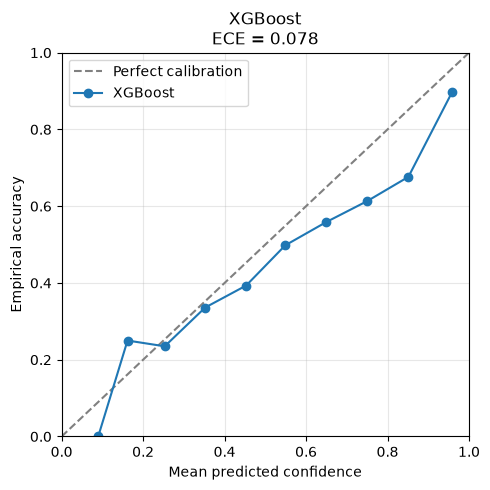

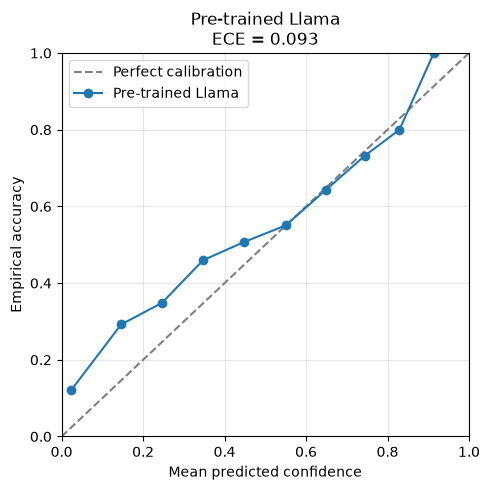

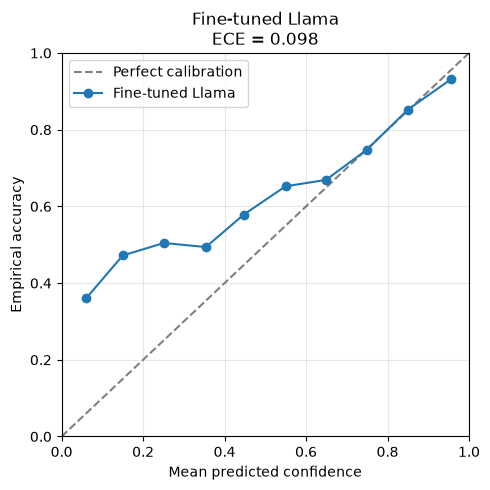

In [55]:
def plot_reliability_diagram(calib_df, model_name, ece):
    # Remove bins vazios, se existirem
    plot_df = calib_df[calib_df["count"] > 0].copy()
    fig, ax = plt.subplots(figsize=(5, 5))

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray",
        label="Perfect calibration"
    )

    ax.plot(
        plot_df["mean_confidence"],
        plot_df["accuracy"],
        marker="o",
        label=model_name
    )

    ax.set_title(f"{model_name}\nECE = {ece:.3f}")
    ax.set_xlabel("Mean predicted confidence")
    ax.set_ylabel("Empirical accuracy")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_reliability_diagram(
    xgb_calib,
    "XGBoost",
    xgb_ece
)

plot_reliability_diagram(
    llama_calib,
    "Pre-trained Llama",
    llama_ece
)

plot_reliability_diagram(
    fine_calib,
    "Fine-tuned Llama",
    fine_ece
)

# Bootstrap Test

In [12]:
data = pd.read_csv("./Datasets/10a_BalancedCalibratedResults.csv")
data['Llama Calibrated Final Proba'] = data['N1 llama Calibrated Proba'] * data['N2 llama Calibrated Proba'] * data['N3 llama Calibrated Proba']
data['Fine Llama Calibrated Final Proba'] = data['N1 fine_llama Calibrated Proba'] * data['N2 fine_llama Calibrated Proba'] * data['N3 fine_llama Calibrated Proba']

In [13]:
data = data.progress_apply(temperature_ensemble, axis=1)

100%|█████████████████████████████████████| 2400/2400 [00:00<00:00, 7021.46it/s]


In [14]:
data.columns

Index(['Label', 'DINAMICA', 'N1 llama Classification', 'N1 llama Pred Proba',
       'N1 llama Pred Log Proba', 'N2 llama Classification',
       'N2 llama Pred Proba', 'N2 llama Pred Log Proba',
       'N3 llama Classification', 'N3 llama Pred Proba',
       'N3 llama Pred Log Proba', 'Llama Final Prediction Proba',
       'N1 fine_llama Classification', 'N1 fine_llama Pred Proba',
       'N1 fine_llama Pred Log Proba', 'N2 fine_llama Classification',
       'N2 fine_llama Pred Proba', 'N2 fine_llama Pred Log Proba',
       'N3 fine_llama Classification', 'N3 fine_llama Pred Proba',
       'N3 fine_llama Pred Log Proba', 'Fine Llama Final Prediction Proba',
       'N1 ML Classification', 'N1 Pred Proba', 'N2 ML Classification',
       'N2 Pred Proba', 'N3 ML Classification', 'N3 Pred Proba',
       'ML Final Prediction Proba', 'Label_N1', 'Label_N2', 'Label_N3',
       'Joint Classification', 'ML + Llama', 'ML + Fine Llama',
       'Llama + Fine Llama', 'N1 llama Correct', 'N2 llama C

In [13]:
def bootstrap_metrics(df, label_col, model_columns, n_bootstrap=1000, random_state=SEED):
    rng = np.random.default_rng(random_state)
    n = len(df)

    results = []

    for i in range(n_bootstrap):
        # Cria o sample com o sorteio das linhas com reposição
        sample_idx = rng.choice(np.arange(n), size=n, replace=True)
        sample = df.iloc[sample_idx]

        # Pega a verdade
        y_true = sample[label_col]

        # Para cada modelo calcula acurácia e f1-score
        for model_name, pred_col in model_columns.items():
            y_pred = sample[pred_col]

            acc = accuracy_score(y_true, y_pred)

            f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

            results.append({
                "bootstrap_id": i,
                "model": model_name,
                "accuracy": acc,
                "f1_score": f1
            })

    return pd.DataFrame(results)

In [18]:
# Mapa do modelo para o nome da coluna de predição
MODEL_COLUMNS = {
    "XGBoost": "N3 ML Classification",
    "Pre-trained Llama": "N3 llama Classification",
    "Fine-tuned Llama": "N3 fine_llama Classification",
    "XGBoost + Pre-trained Llama": "ML + Llama",
    "XGBoost + Fine-tuned Llama": "ML + Fine Llama",
    "Pre-trained Llama + Fine-tuned Llama": "Llama + Fine Llama",
    "Joint": "Joint Classification"
}

inicio = time.time()
bootstrap_results = bootstrap_metrics(
    df=data,
    label_col="Label",
    model_columns=MODEL_COLUMNS,
    n_bootstrap=1000,
    random_state=SEED
)
fim = time.time()

print(f"{fim - inicio}")

bootstrap_results.head()

160.15429639816284


,bootstrap_id,model,accuracy,f1_score
0,0,XGBoost,0.560417,0.551477
1,0,Pre-trained Llama,0.267917,0.234606
2,0,Fine-tuned Llama,0.657917,0.639605
3,0,XGBoost + Pre-trained Llama,0.562083,0.551265
4,0,XGBoost + Fine-tuned Llama,0.631667,0.618852


In [19]:
bootstrap_results.shape

(7000, 4)

In [20]:
bootstrap_results.groupby("model")[["accuracy", "f1_score"]].mean()

,accuracy,f1_score
model,,
Fine-tuned Llama,0.668995,0.644472
Joint,0.624567,0.603096
Pre-trained Llama,0.276515,0.246248
Pre-trained Llama + Fine-tuned Llama,0.597755,0.592332
XGBoost,0.564562,0.550207
XGBoost + Fine-tuned Llama,0.628756,0.609348
XGBoost + Pre-trained Llama,0.569512,0.553002


In [22]:
def bootstrap_ci_summary(bootstrap_results, lower=2.5, upper=97.5):
    bootstrap_results_grouped = bootstrap_results.groupby("model")
    
    bootstrap_agg = bootstrap_results_grouped.agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_ci_lower=("accuracy", lambda x: np.percentile(x, lower)),
        accuracy_ci_upper=("accuracy", lambda x: np.percentile(x, upper)),
        f1_mean=("f1_score", "mean"),
        f1_ci_lower=("f1_score", lambda x: np.percentile(x, lower)),
        f1_ci_upper=("f1_score", lambda x: np.percentile(x, upper))
    )
    
    return bootstrap_agg.reset_index()

In [23]:
bootstrap_ci = bootstrap_ci_summary(bootstrap_results)
bootstrap_ci

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,f1_mean,f1_ci_lower,f1_ci_upper
0,Fine-tuned Llama,0.668995,0.650417,0.687500,0.644472,0.626554,0.663279
1,Joint,0.624567,0.603333,0.643760,0.603096,0.585392,0.620162
2,Pre-trained Llama,0.276515,0.258750,0.295417,0.246248,0.231544,0.261493
3,Pre-trained Llama + Fine-tuned Llama,0.597755,0.578333,0.617083,0.592332,0.574723,0.611402
4,XGBoost,0.564562,0.545000,0.584583,0.550207,0.532439,0.567103
5,XGBoost + Fine-tuned Llama,0.628756,0.608333,0.647500,0.609348,0.591425,0.626698
6,XGBoost + Pre-trained Llama,0.569512,0.550406,0.588760,0.553002,0.536165,0.569867


In [24]:
def bootstrap_pairwise_differences(bootstrap_results, comparisons):
    results = []

    for model_a, model_b in comparisons:
        a = bootstrap_results[bootstrap_results["model"] == model_a].copy()
        b = bootstrap_results[bootstrap_results["model"] == model_b].copy()

        merged = a.merge(b, on="bootstrap_id", suffixes=("_a", "_b"))
        merged["accuracy_diff"] = (merged["accuracy_a"] - merged["accuracy_b"])
        merged["f1_diff"] = (merged["f1_score_a"] - merged["f1_score_b"])

        results.append(
            {
                "comparison": f"{model_a} - {model_b}",
                "accuracy_diff_mean": merged["accuracy_diff"].mean(),
                "accuracy_diff_ci_lower": np.percentile(merged["accuracy_diff"], 2.5),
                "accuracy_diff_ci_upper": np.percentile(merged["accuracy_diff"], 97.5),
                "f1_diff_mean": merged["f1_diff"].mean(),
                "f1_diff_ci_lower": np.percentile(merged["f1_diff"], 2.5),
                "f1_diff_ci_upper": np.percentile(merged["f1_diff"], 97.5)
            }
        )

    return pd.DataFrame(results)

In [26]:
comparisons = [
    ('XGBoost', 'Pre-trained Llama'),
    ('XGBoost', 'Fine-tuned Llama'),
    ('XGBoost', 'XGBoost + Pre-trained Llama'),
    ('XGBoost', 'XGBoost + Fine-tuned Llama'),
    ('XGBoost', 'Pre-trained Llama + Fine-tuned Llama'),
    ('XGBoost', 'Joint'),
    
    ('Pre-trained Llama', 'Fine-tuned Llama'),
    ('Pre-trained Llama', 'XGBoost + Pre-trained Llama'),
    ('Pre-trained Llama', 'XGBoost + Fine-tuned Llama'),
    ('Pre-trained Llama', 'Pre-trained Llama + Fine-tuned Llama'),
    ('Pre-trained Llama', 'Joint'),
    
    ('Fine-tuned Llama', 'XGBoost + Pre-trained Llama'),
    ('Fine-tuned Llama', 'XGBoost + Fine-tuned Llama'),
    ('Fine-tuned Llama', 'Pre-trained Llama + Fine-tuned Llama'),
    ('Fine-tuned Llama', 'Joint'),
    
    ('XGBoost + Pre-trained Llama', 'XGBoost + Fine-tuned Llama'),
    ('XGBoost + Pre-trained Llama', 'Pre-trained Llama + Fine-tuned Llama'),
    ('XGBoost + Pre-trained Llama', 'Joint'),
    
    ('XGBoost + Fine-tuned Llama', 'Pre-trained Llama + Fine-tuned Llama'),
    ('XGBoost + Fine-tuned Llama', 'Joint'),
    
    ('Pre-trained Llama + Fine-tuned Llama', 'Joint')
]

In [27]:
bootstrap_differences = bootstrap_pairwise_differences(bootstrap_results, comparisons)
bootstrap_differences

,comparison,accuracy_diff_mean,accuracy_diff_ci_lower,accuracy_diff_ci_upper,f1_diff_mean,f1_diff_ci_lower,f1_diff_ci_upper
0,XGBoost - Pre-trained Llama,0.288047,0.264156,0.310844,0.303959,0.282782,0.325357
1,XGBoost - Fine-tuned Llama,-0.104432,-0.123333,-0.085833,-0.094265,-0.114491,-0.073669
2,XGBoost - XGBoost + Pre-trained Llama,-0.004950,-0.011667,0.002083,-0.002795,-0.009532,0.004453
3,XGBoost - XGBoost + Fine-tuned Llama,-0.064194,-0.077500,-0.050823,-0.059142,-0.072311,-0.045568
4,XGBoost - Pre-trained Llama + Fine-tuned Llama,-0.033192,-0.054583,-0.011250,-0.042126,-0.062872,-0.021105
5,XGBoost - Joint,-0.060005,-0.074177,-0.045823,-0.052890,-0.067799,-0.038024
6,Pre-trained Llama - Fine-tuned Llama,-0.392480,-0.413750,-0.370406,-0.398224,-0.418286,-0.378018
7,Pre-trained Llama - XGBoost + Pre-trained Llama,-0.292997,-0.315000,-0.271667,-0.306754,-0.326434,-0.286469
8,Pre-trained Llama - XGBoost + Fine-tuned Llama,-0.352241,-0.375000,-0.328750,-0.363100,-0.383273,-0.343248
9,Pre-trained Llama - Pre-trained Llama + Fine-t...,-0.321239,-0.342083,-0.300000,-0.346084,-0.366914,-0.326033


# Hierarchical Metrics

In [15]:
data = pd.read_csv("./Datasets/10a_BalancedCalibratedResults.csv")
data['Llama Calibrated Final Proba'] = data['N1 llama Calibrated Proba'] * data['N2 llama Calibrated Proba'] * data['N3 llama Calibrated Proba']
data['Fine Llama Calibrated Final Proba'] = data['N1 fine_llama Calibrated Proba'] * data['N2 fine_llama Calibrated Proba'] * data['N3 fine_llama Calibrated Proba']
data = data.progress_apply(temperature_ensemble, axis=1)

100%|█████████████████████████████████████| 2400/2400 [00:00<00:00, 8903.84it/s]


In [16]:
data.columns

Index(['Label', 'DINAMICA', 'N1 llama Classification', 'N1 llama Pred Proba',
       'N1 llama Pred Log Proba', 'N2 llama Classification',
       'N2 llama Pred Proba', 'N2 llama Pred Log Proba',
       'N3 llama Classification', 'N3 llama Pred Proba',
       'N3 llama Pred Log Proba', 'Llama Final Prediction Proba',
       'N1 fine_llama Classification', 'N1 fine_llama Pred Proba',
       'N1 fine_llama Pred Log Proba', 'N2 fine_llama Classification',
       'N2 fine_llama Pred Proba', 'N2 fine_llama Pred Log Proba',
       'N3 fine_llama Classification', 'N3 fine_llama Pred Proba',
       'N3 fine_llama Pred Log Proba', 'Fine Llama Final Prediction Proba',
       'N1 ML Classification', 'N1 Pred Proba', 'N2 ML Classification',
       'N2 Pred Proba', 'N3 ML Classification', 'N3 Pred Proba',
       'ML Final Prediction Proba', 'Label_N1', 'Label_N2', 'Label_N3',
       'Joint Classification', 'ML + Llama', 'ML + Fine Llama',
       'Llama + Fine Llama', 'N1 llama Correct', 'N2 llama C

In [34]:
# ============================================================
# Hierarchical metrics following Silla & Freitas (2011)
#
# hP = sum_i |P_i ∩ T_i| / sum_i |P_i|
# hR = sum_i |P_i ∩ T_i| / sum_i |T_i|
# hF = 2 * hP * hR / (hP + hR)
#
# Root node is not included.
# "Unclassified" is treated as an incorrect predicted label.
# ============================================================

true_cols = ["Label_N1", "Label_N2", "Label_N3"]

models = {
    "XGBoost": [
        "N1 ML Classification",
        "N2 ML Classification",
        "N3 ML Classification"
    ],
    "Pre-trained Llama": [
        "N1 llama Classification",
        "N2 llama Classification",
        "N3 llama Classification"
    ],
    "Fine-tuned Llama": [
        "N1 fine_llama Classification",
        "N2 fine_llama Classification",
        "N3 fine_llama Classification"
    ]
}


def get_path(row, columns):
    path = []

    for col in columns:
        value = row[col]

        if pd.notna(value):
            path.append(value)

    return path


def compute_hierarchical_metrics(df, pred_cols):
    total_intersection = 0
    total_predicted = 0
    total_true = 0

    for _, row in df.iterrows():
        true_path = set(get_path(row, true_cols))
        pred_path = set(get_path(row, pred_cols))

        total_intersection += len(true_path.intersection(pred_path))
        total_predicted += len(pred_path)
        total_true += len(true_path)

    h_precision = total_intersection / total_predicted if total_predicted > 0 else 0
    h_recall = total_intersection / total_true if total_true > 0 else 0

    if h_precision + h_recall > 0:
        h_f1 = 2 * h_precision * h_recall / (h_precision + h_recall)
    else:
        h_f1 = 0

    return h_precision, h_recall, h_f1


results = []

for model_name, pred_cols in models.items():
    h_precision, h_recall, h_f1 = compute_hierarchical_metrics(data, pred_cols)

    results.append({
        "Model": model_name,
        "Hierarchical Precision": h_precision,
        "Hierarchical Recall": h_recall,
        "Hierarchical F1-score": h_f1
    })

hierarchical_metrics_df = pd.DataFrame(results)

hierarchical_metrics_df

,Model,Hierarchical Precision,Hierarchical Recall,Hierarchical F1-score
0,XGBoost,0.732013,0.703044,0.717236
1,Pre-trained Llama,0.454615,0.453577,0.454095
2,Fine-tuned Llama,0.809153,0.791172,0.800062
